# SQL-Gen Analysis — Workload Diversity Evaluation

Coherent, paper-facing evaluation of the query generator against hand-crafted and
generated baselines on TPC-DS. Layout mirrors the paper:

| Section | Table / figure | What it answers |
|---|---|---|
| 0 · Load | — | workloads, universes, styler |
| 1 · Structural diversity | **Table 1** | Are the physical plans distinct, broad, and spread out? |
| 2 · Schema diversity | **Table 2** | Do we touch the whole schema? |
| 3 · Quality & overhead | **Table 3** | Valid, and at what cost? |
| 4 · Analysis: exploration & evenness | figures | Where feedback helps; why raw evenness misranks |

**Headline metric: plan-graph Vendi** (effective number of distinct plans). The
structural table is the thesis; entropy/evenness lives in §4 as *analysis*, not a
scoreboard (it rewards narrowness — see the SQLBarber exhibit).

## 0 · Load workloads, universes, styler

In [ ]:
import json, glob, math
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REF       = "tpcds"                              
OURS      = ["gpt_generated_1000_tpcds_new"]     
BASELINES = ["sqlstorm_1000_tpcds", 
             "sqlbarber_1000_tpcds", 
             "sql_factory_1000_tpcds",
             "e2etune_1000_tpcds", 
             "bootstrapping_lcm_1000_tpcds"
             ]


plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

# --- load every results CSV; newer file wins on duplicate workload names ------
_files = sorted(glob.glob("results/*.csv"), key=lambda p: Path(p).stat().st_mtime)
df = (pd.concat([pd.read_csv(p) for p in _files], ignore_index=True)
        .drop_duplicates("workload", keep="last").set_index("workload"))


ROWS = [REF] + OURS + BASELINES
missing = [w for w in ROWS if w not in df.index]
assert not missing, f"missing workloads: {missing}"

# --- fixed universes (same denominator for every workload) -------------------
_ops = pd.read_csv(Path("../resources/operators_ground_truth.csv"))
U_OP = int((_ops["category"].astype(str).str.lower() != "dml").sum())   # non-DML operators
print(f"operator universe |U| = {U_OP} (non-DML operators)")

WORKLOAD_ROOTS = [Path("../../Workloads"), Path("/mnt/primary/Main/Workloads")]
def find_report(w):
    for r in WORKLOAD_ROOTS:
        p = Path(r) / w / "generation_report.json"
        if p.exists():
            return json.loads(p.read_text(encoding="utf-8"))
    return None
reports = {w: r for w in ROWS if (r := find_report(w)) is not None}

# --- pretty names + colours + styler -----------------------------------------
PRETTY = {"tpcds":"TPC-DS (ref)", "gpt_generated_1000_tpcds_new":"Ours",
          "sqlstorm_1000_tpcds":"SQLStorm", "sqlbarber_1000_tpcds":"SQLBarber",
          "sql_factory_1000_tpcds":"SQL-Factory", "e2etune_1000_tpcds":"E2ETune",
          "bootstrapping_lcm_1000_tpcds":"Bootstrapping-LCM"}

COL = {w: "#b8b8b8" for w in ROWS}
for w in OURS: COL[w] = "#ea580c"
COL[REF] = "#111111"
_INV = {v:k for k,v in PRETTY.items()}

def show(tbl, fmt="{:.3f}", **kw):
    disp = tbl.rename(index=PRETTY)
    def hl(row):
        key = _INV.get(row.name, row.name)
        if key == REF:  return ["background-color:#f3f4f6;font-style:italic"]*len(row)
        if key in OURS: return ["background-color:#fff1e6;font-weight:600"]*len(row)
        return [""]*len(row)
    sty = disp.style.apply(hl, axis=1)
    return sty.format(fmt, **kw) if fmt else sty


operator universe |U| = 57 (non-DML operators)


## 1 · Structural diversity  —  **Table 1**

Distinctness, breadth and spread of the compiled physical plans. **Plan-graph
Vendi** (rightmost) is the headline: the effective number of structurally distinct
plans. The others corroborate it — *operator coverage* (breadth of the operator
space), *unique plan-graph ratio* (share of non-duplicate plans), and *mean NN
distance* (spread, so a high Vendi can't be a few outliers).

In [3]:
table1 = pd.DataFrame({
    "Operator types":          df.loc[ROWS, "n_operator_types_observed"],
    "Operator cov. (K/|U|)":   df.loc[ROWS, "n_operator_types_observed"] / U_OP,
    "Unique plan-graph ratio": df.loc[ROWS, "plan_graph_uniqueness_ratio"],
    "Mean NN distance":        df.loc[ROWS, "mean_nearest_neighbour_distance"],
    "Plan-graph Vendi":        df.loc[ROWS, "plan_graph_vendi_score"],
}, index=ROWS).astype(float)

show(table1, None).format({
    "Operator types": "{:.0f}", "Operator cov. (K/|U|)": "{:.2f}",
    "Unique plan-graph ratio": "{:.3f}", "Mean NN distance": "{:.3f}",
    "Plan-graph Vendi": "{:.1f}",
})

,Operator types,Operator cov. (K/|U|),Unique plan-graph ratio,Mean NN distance,Plan-graph Vendi
TPC-DS (ref),29,0.51,0.848,0.243,22.3
Ours,37,0.65,1.000,0.375,109.6
SQLStorm,32,0.56,0.791,0.270,79.5
SQLBarber,26,0.46,0.119,0.001,19.5
SQL-Factory,33,0.58,0.937,0.203,51.2
E2ETune,31,0.54,0.984,0.251,55.6
Bootstrapping-LCM,29,0.51,0.935,0.138,18.9


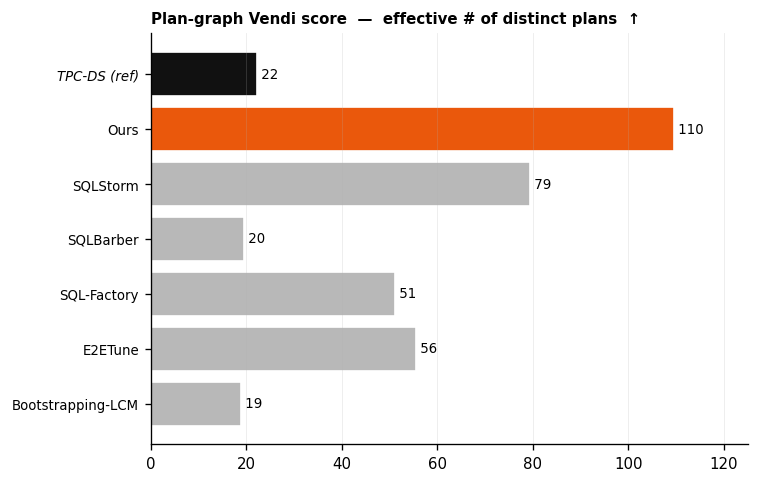

In [4]:
# headline figure: plan-graph Vendi
fig, ax = plt.subplots(figsize=(6.4, 0.5*len(ROWS)+0.6))
vals = table1["Plan-graph Vendi"]
ax.barh(range(len(ROWS)), vals.values, color=[COL[w] for w in ROWS], edgecolor="white")
for i, v in enumerate(vals.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8)
ax.set_yticks(range(len(ROWS))); ax.set_yticklabels([PRETTY[w] for w in ROWS], fontsize=8)
ax.get_yticklabels()[0].set_fontstyle("italic")
ax.invert_yaxis(); ax.margins(x=0.14); ax.grid(axis="y", visible=False)
ax.set_title("Plan-graph Vendi score  —  effective # of distinct plans  ↑",
             loc="left", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

## 2 · Schema diversity  —  **Table 2**

Do the queries touch the whole schema, and are table combinations varied?
*Coverage* is the fraction of tables / columns / FK-edges referenced anywhere;
*unique table-set ratio* is the share of distinct table combinations. All in
`[0,1]`, higher is better. (Usage **entropy** is deferred to §4.)

In [5]:
table2 = pd.DataFrame({
    "Table cov.":              df.loc[ROWS, "table_coverage"],
    "Column cov.":             df.loc[ROWS, "column_coverage"],
    "Join-edge cov.":          df.loc[ROWS, "join_edge_coverage"],
    "Unique table-set ratio":  df.loc[ROWS, "unique_table_set_ratio"],
}, index=ROWS).astype(float)

show(table2)

,Table cov.,Column cov.,Join-edge cov.,Unique table-set ratio
TPC-DS (ref),1.000,0.581,0.683,0.657
Ours,1.000,0.979,1.000,0.924
SQLStorm,1.000,0.732,0.841,0.418
SQLBarber,1.000,0.553,0.939,0.124
SQL-Factory,1.000,0.781,1.000,0.376
E2ETune,1.000,0.889,1.000,0.877
Bootstrapping-LCM,0.958,0.802,0.988,0.398


## 3 · Quality & overhead  —  **Table 3**

*Validity* = queries that parse **and** execute / queries requested (baselines are
distributed pre-validated, so they read ~100%). Overhead (wall-clock, throughput)
is only defined for generators we ran end-to-end; external baselines show —.

In [ ]:
def _get(w, col):
    # tolerant: missing column (older CSVs) or missing value -> NaN, never an error
    v = df.loc[w].get(col, np.nan) if col in df.columns else np.nan
    return float(v) if pd.notna(v) else np.nan

table3 = pd.DataFrame({
    "Validity %":      df.loc[ROWS, "ok"] / df.loc[ROWS, "query_count"] * 100,
    "Gen. time (min)": [ _get(w, "gen_duration_s")/60.0 for w in ROWS ],
    "Queries / min":   [ _get(w, "gen_queries_per_min") for w in ROWS ],
    "Sec / query":     [ _get(w, "gen_seconds_per_query") for w in ROWS ],
    "Tokens / query":  [ _get(w, "gen_tokens_per_query") for w in ROWS ],   # blank for pre-token CSVs
    "Reject rate":     [ _get(w, "gen_rejection_rate") for w in ROWS ],
}, index=ROWS)

show(table3, None).format({
    "Validity %": "{:.1f}", "Gen. time (min)": "{:.1f}", "Queries / min": "{:.2f}",
    "Sec / query": "{:.1f}", "Tokens / query": "{:,.0f}", "Reject rate": "{:.1%}",
}, na_rep="—")

## 4 · Analysis: exploration & the evenness artifact

This section is the paper's *characterisation*, not a scoreboard. Two linked points.

### 4a · Why we don't report operator/n-gram **entropy** as a headline
The usual metric is Pielou **evenness** `H / ln(K_obs)`, normalised by the number
of distinct elements *that workload happened to touch*. That denominator rewards
**narrowness**: a generator that discovers more operator types is divided by a
larger `ln K`, so it scores lower evenness even at equal raw entropy. The exhibit
below: **SQLBarber tops operator evenness while being the least diverse workload by
every count metric** (plan-uniqueness 0.12, mean-NN 0.001, Vendi 19). A metric that
crowns near-duplicates as "most uniform" is measuring the wrong thing.

We instead read two fair quantities: the **effective number** `N1 = exp(H) =
K^evenness` (universe-free, the same "effective number" idea as Vendi) and
**fixed-universe evenness** `E* = H / ln|U|` (shared denominator). On these we are
on par with the strongest baselines while covering strictly more of the space — so
the apparent operator-entropy "gap" is a normalisation artifact.

In [7]:
def fixed_evenness(ev, k, U):
    return (ev*math.log(k))/math.log(U) if (k and k>1 and U>1) else np.nan
def effective_number(ev, k):
    return math.exp(ev*math.log(k)) if (k and k>1) else np.nan

_K  = df.loc[ROWS, "n_operator_types_observed"].astype(float)
_EV = df.loc[ROWS, "operator_type_entropy"].astype(float)
evenness = pd.DataFrame({
    "Operator types (K)":    _K,
    "Evenness (obs, H/lnK)": _EV,                                    # the misleading metric
    "Effective # (N1)":      [effective_number(e,k) for e,k in zip(_EV,_K)],
    "Evenness (fixed |U|)":  [fixed_evenness(e,k,U_OP) for e,k in zip(_EV,_K)],
}, index=ROWS)
show(evenness, None).format({
    "Operator types (K)":"{:.0f}", "Evenness (obs, H/lnK)":"{:.3f}",
    "Effective # (N1)":"{:.2f}", "Evenness (fixed |U|)":"{:.3f}",
})

,Operator types (K),"Evenness (obs, H/lnK)",Effective # (N1),Evenness (fixed |U|)
TPC-DS (ref),29,0.680,9.88,0.567
Ours,37,0.659,10.79,0.588
SQLStorm,32,0.709,11.65,0.607
SQLBarber,26,0.733,10.90,0.591
SQL-Factory,33,0.719,12.34,0.622
E2ETune,31,0.717,11.73,0.609
Bootstrapping-LCM,29,0.668,9.49,0.557


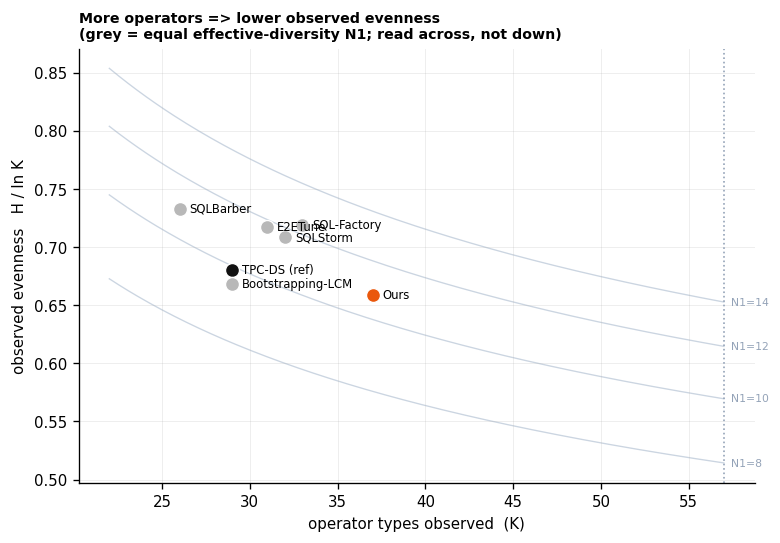

In [8]:
# the artifact, visualised: along a constant effective-diversity (N1) curve,
# evenness MUST fall as K rises  ->  broad generators are pushed down the axis.
fig, ax = plt.subplots(figsize=(6.6, 4.6))
_k = np.linspace(22, U_OP, 200)
for n1 in [8, 10, 12, 14]:
    ax.plot(_k, np.log(n1)/np.log(_k), color="#cbd5e1", lw=0.8, zorder=1)
    ax.text(U_OP, np.log(n1)/np.log(U_OP), f"  N1={n1}", fontsize=6.5, color="#94a3b8", va="center")
for w in ROWS:
    k, e = float(df.loc[w,"n_operator_types_observed"]), float(df.loc[w,"operator_type_entropy"])
    ax.scatter(k, e, color=COL[w], s=70, edgecolor="white", lw=0.8, zorder=3)
    ax.annotate(PRETTY[w], (k,e), fontsize=7, xytext=(6,0), textcoords="offset points", va="center")
ax.axvline(U_OP, color="#94a3b8", ls=":", lw=1)
ax.set_xlabel("operator types observed  (K)"); ax.set_ylabel("observed evenness   H / ln K")
ax.set_title("More operators => lower observed evenness\n(grey = equal effective-diversity N1; read across, not down)",
             loc="left", fontsize=8.5, fontweight="bold")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

### 4b · Exploration dynamics: where coverage feedback helps

Sub-hypothesis: coverage feedback raises diversity **only while the operator
vocabulary is unsaturated**; once the ceiling is hit, selection-side steering
converges to the no-feedback baseline and further gains need generation-side
levers. Evidence below is the **discovery rate** (new operators per accepted query)
early vs late in each of our runs — a sharp early-to-late drop is the saturation
signature. *(The formal feedback-on vs feedback-off ablation is the one run still
pending; drop it in here when ready.)*

In [9]:
rows = []
for w, rep in reports.items():
    pf = rep.get("plan_feedback", {})
    rows.append({
        "workload": PRETTY.get(w, w),
        "operators covered": pf.get("operators_covered"),
        "reachable": pf.get("operators_reachable"),
        "discovery rate (first 100)": pf.get("discovery_rate_first100"),
        "discovery rate (last 100)":  pf.get("discovery_rate_last100"),
    })
disc = pd.DataFrame(rows).set_index("workload")
disc if len(disc) else print("no plan_feedback in loaded reports")

,operators covered,reachable,discovery rate (first 100),discovery rate (last 100)
workload,,,,
Ours,12.0,25.0,2.89,0.45
SQLStorm,NaN,NaN,NaN,NaN
SQLBarber,NaN,NaN,NaN,NaN
SQL-Factory,NaN,NaN,NaN,NaN
E2ETune,NaN,NaN,NaN,NaN
Bootstrapping-LCM,NaN,NaN,NaN,NaN


---
**Reported set (nothing else in headline tables).** Table 1: operator types,
operator coverage, unique plan-graph ratio, mean NN distance, plan-graph Vendi.
Table 2: table / column / join-edge coverage, unique table-set ratio. Table 3:
validity %, generation time, throughput. §4 (analysis only): effective number /
fixed-|U| evenness, exploration dynamics.